# AlphaLens XGBoost Experiment

This notebook selects a regularized XGBoost regressor using only the purged chronological validation period. The selected parameters and validation-selected tree count are refit on train plus validation, then compared once with the locked test baselines.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.features import build_event_feature_dataset
from pipelines.ml.xgboost_model import run_xgboost_experiment

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

## Validation-only model selection

In [2]:
dataset = build_event_feature_dataset(horizon=30, include_topics=True)
experiment = run_xgboost_experiment(dataset)
display(pd.Series(experiment.selected_parameters, name='value'))
print('Selected boosting rounds:', experiment.selected_boosting_rounds)

max_depth           2.00
learning_rate       0.03
min_child_weight    5.00
subsample           0.80
colsample_bytree    0.80
reg_lambda          5.00
reg_alpha           0.00
Name: value, dtype: float64

Selected boosting rounds: 69


In [3]:
validation = experiment.validation_metrics.drop(columns=['parameters']).copy()
display(validation[['model', 'mae', 'rmse', 'directional_accuracy', 'pearson', 'spearman_ic', 'boosting_rounds']])

,model,mae,rmse,directional_accuracy,pearson,spearman_ic,boosting_rounds
0,xgb_01,0.075663,0.107805,0.552632,0.140060,0.125961,69
1,xgb_03,0.076162,0.108664,0.565789,0.044746,0.070339,23
2,xgb_04,0.076403,0.108536,0.552632,0.069644,0.089421,5
3,xgb_06,0.076508,0.108683,0.513158,0.039709,0.053613,3
4,xgb_02,0.076514,0.108114,0.565789,0.128058,0.084886,18
5,xgb_05,0.076528,0.108607,0.519737,0.114435,0.101620,3
6,zero_excess,0.076562,0.108737,0.394737,NaN,NaN,<NA>
7,historical_mean,0.076570,0.108741,0.394737,NaN,NaN,<NA>
8,ridge_alpha_100,0.079085,0.112099,0.532895,-0.013064,0.056664,<NA>
9,ridge_alpha_10,0.086641,0.120841,0.467105,-0.085414,-0.017243,<NA>


## Untouched test comparison

The test period does not choose parameters, tree count, or features. It answers only whether the already-selected model generalizes better than the simple hurdles.

,model,mae,rmse,r2,directional_accuracy,pearson,spearman_ic
0,historical_mean,0.062660,0.082695,-0.000030,0.529801,NaN,NaN
1,zero_excess,0.062781,0.082733,-0.000947,0.470199,NaN,NaN
2,xgboost_selected_01,0.063018,0.083351,-0.015955,0.523179,-0.032637,-0.105710
3,ridge_alpha_100,0.067925,0.090156,-0.188627,0.443709,-0.117977,-0.211628


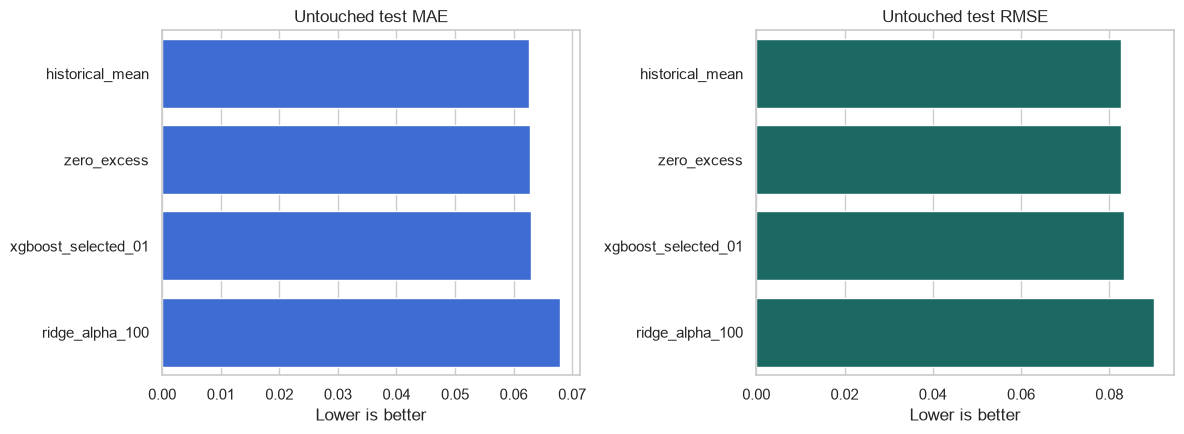

In [4]:
test_metrics = experiment.test_metrics.drop(columns=['parameters']).copy()
display(test_metrics[['model', 'mae', 'rmse', 'r2', 'directional_accuracy', 'pearson', 'spearman_ic']])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=test_metrics, x='mae', y='model', ax=axes[0], color='#2563eb')
sns.barplot(data=test_metrics, x='rmse', y='model', ax=axes[1], color='#0f766e')
axes[0].set(title='Untouched test MAE', xlabel='Lower is better', ylabel='')
axes[1].set(title='Untouched test RMSE', xlabel='Lower is better', ylabel='')
plt.tight_layout()
plt.show()

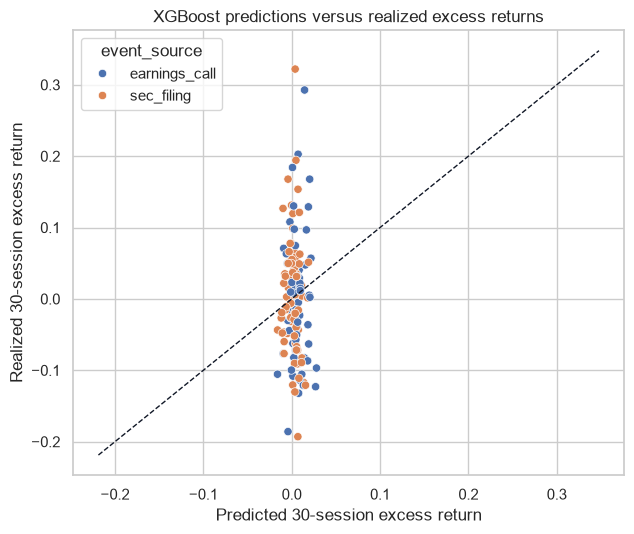

In [5]:
xgb_predictions = experiment.test_predictions.loc[
    experiment.test_predictions['model'].str.startswith('xgboost')
].copy()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.scatterplot(data=xgb_predictions, x='prediction', y='excess_return_30d', hue='event_source', ax=ax)
limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(limits, limits, linestyle='--', color='#111827', linewidth=1)
ax.set(title='XGBoost predictions versus realized excess returns', xlabel='Predicted 30-session excess return', ylabel='Realized 30-session excess return')
plt.tight_layout()
plt.show()

## Decision rule

A complex model is not promoted merely because it fits. It must improve untouched test MAE or RMSE and show credible directional or rank behavior. A near miss is retained as an experiment result, while the historical-mean predictor remains the deployment hurdle.